# 04 — Evaluation
Part of the *Kenya Household Food Security Classification* capstone project.

Disaggregated evaluation and error analysis (Section 10), feature importance
(Section 11), Responsible AI notes and a single-household prediction demo
(Section 12), and finally exporting the deployable model bundle for the web app.

**Input:** `data/processed/03_model.pkl` (from `03_modelling.ipynb`), plus the raw
CSVs (only for the Section 12 demo, which needs an example raw household record)
**Output:** `models/model_artifacts.pkl` (consumed by the Render/Streamlit app)


## Setup

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
path = "/content/drive/MyDrive/Ngao Labs Program/Capstone Project"

In [34]:
print(f"Current value of 'path' variable: {path}")

Current value of 'path' variable: /content/drive/MyDrive/Ngao Labs Program/Capstone Project


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import pickle
import warnings
import os # Import os for path manipulation
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Install catboost if not already installed, as the model artifact might depend on it
try:
    import catboost
except ImportError:
    !pip install catboost


# Construct the full path using os.path.join for the model
model_path = os.path.join(path, 'data', 'processed', '03_model.pkl')

with open(model_path, 'rb') as f:
    _S = pickle.load(f)
locals().update(_S)

print('Loaded modelling artifacts. Winning model:', best_name)

# Raw w4/a4 are only needed for the Section 12 single-household demo below,
# which reconstructs one example household from the raw tables.
# IMPORTANT: The 'path' variable should NOT be redefined here to avoid conflicts.
raw_hh_filepath = os.path.join(path, 'data', 'raw', 'hh.csv')
raw_adult_filepath = os.path.join(path, 'data', 'raw', 'adult.csv')

w4 = pd.read_csv(raw_hh_filepath, low_memory=False)
a4 = pd.read_csv(raw_adult_filepath, low_memory=False)
if 'wave' in w4.columns and w4['wave'].nunique() > 1:
    w4 = w4[w4['wave'] == 4].copy()
if 'wave' in a4.columns and a4['wave'].nunique() > 1:
    a4 = a4[a4['wave'] == 4].copy()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/data/processed/03_model.pkl'

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import pickle
import warnings
import os # Import os for path manipulation
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Install catboost if not already installed, as the model artifact might depend on it
try:
    import catboost
except ImportError:
    !pip install catboost

print(f"DEBUG: Path before model_path construction: {path}")
# The 'path' variable from cell ob4CaZMe-pOs is assumed to be the 'Capstone Project' directory.
# The model artifact is expected in 'data/processed/' directory relative to the project path.
model_path = os.path.join(path, 'data', 'processed', '03_model.pkl')
print(f"DEBUG: Constructed model_path: {model_path}")

with open(model_path, 'rb') as f:
    _S = pickle.load(f)
locals().update(_S)

print('Loaded modelling artifacts. Winning model:', best_name)

# Raw w4/a4 are only needed for the Section 12 single-household demo below,
# which reconstructs one example household from the raw tables.
# IMPORTANT: The 'path' variable should NOT be redefined here to avoid conflicts.
raw_data_dir = os.path.join(path, 'data', 'raw')
print(f"DEBUG: Checking contents of raw data directory: {raw_data_dir}")
# List contents of the raw data directory to diagnose FileNotFoundError
!ls -F '{raw_data_dir}'

raw_hh_filepath = os.path.join(raw_data_dir, 'hh.csv')
raw_adult_filepath = os.path.join(raw_data_dir, 'hh_adult.csv')

w4 = pd.read_csv(raw_hh_filepath, low_memory=False)
a4 = pd.read_csv(raw_adult_filepath, low_memory=False)
if 'wave' in w4.columns and w4['wave'].nunique() > 1:
    w4 = w4[w4['wave'] == 4].copy()
if 'wave' in a4.columns and a4['wave'].nunique() > 1:
    a4 = a4[a4['wave'] == 4].copy()

DEBUG: Path before model_path construction: /content/drive/MyDrive/Ngao Labs Program/Capstone Project
DEBUG: Constructed model_path: /content/drive/MyDrive/Ngao Labs Program/Capstone Project/data/processed/03_model.pkl
Loaded modelling artifacts. Winning model: XGBoost (default + balanced weights)
DEBUG: Checking contents of raw data directory: /content/drive/MyDrive/Ngao Labs Program/Capstone Project/data/raw
hh_adult.csv  hh.csv


## 10. Evaluation

### 10.1 Disaggregated evaluation (Urban vs Rural, by County)

In [43]:
print("Weighted / Macro F1 by urban/rural subgroup:")
for grp_val, grp_name in [(0, 'Rural'), (1, 'Urban')]:
    mask = (urban_test.values == grp_val)
    wf1 = f1_score(y_test[mask], final_y_pred[mask], average='weighted')
    mf1 = f1_score(y_test[mask], final_y_pred[mask], average='macro')
    print(f"  {grp_name:6s} (n={mask.sum():4d}): weighted F1={wf1:.3f}, macro F1={mf1:.3f}")

print("\nWeighted F1 by county (counties with at least 10 test households):")
county_rows = []
for county in sorted(county_test.unique()):
    mask = (county_test.values == county)
    if mask.sum() >= 10:
        wf1 = f1_score(y_test[mask], final_y_pred[mask], average='weighted')
        county_rows.append({'county': county, 'n': int(mask.sum()), 'weighted_f1': round(wf1, 3)})
county_eval = pd.DataFrame(county_rows).sort_values('weighted_f1')
print(county_eval.to_string(index=False))

Weighted / Macro F1 by urban/rural subgroup:
  Rural  (n= 456): weighted F1=0.507, macro F1=0.436
  Urban  (n= 523): weighted F1=0.563, macro F1=0.469

Weighted F1 by county (counties with at least 10 test households):
 county  n  weighted_f1
     37 34        0.349
     21 15        0.374
     15 22        0.378
     30 23        0.380
     45 32        0.381
      5 17        0.402
     31 19        0.428
     36 12        0.435
     16 31        0.450
     28 16        0.474
     42 43        0.475
     13 21        0.478
     46 22        0.509
     43 20        0.520
      2 18        0.520
     14 22        0.520
     26 32        0.527
     18 26        0.535
     29 13        0.538
     41 31        0.544
     47 57        0.552
     39 34        0.554
     22 25        0.561
     32 38        0.585
     40 27        0.593
     35 21        0.598
     44 24        0.603
      6 23        0.605
      1 18        0.627
      4 17        0.630
     10 15        0.636
     17 22   

### 10.2 Error analysis

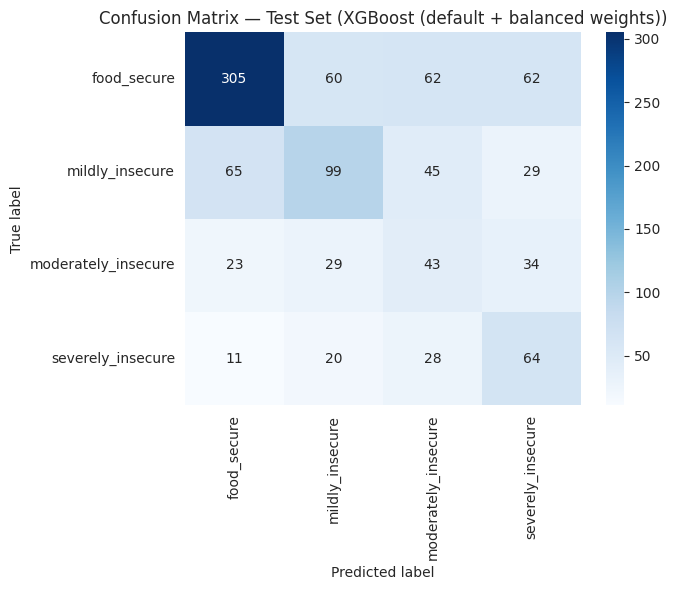

Share of genuinely insecure households misclassified as food_secure: 20.2%
                     precision    recall  f1-score   support

        food_secure       0.75      0.62      0.68       489
    mildly_insecure       0.48      0.42      0.44       238
moderately_insecure       0.24      0.33      0.28       129
  severely_insecure       0.34      0.52      0.41       123

           accuracy                           0.52       979
          macro avg       0.45      0.47      0.45       979
       weighted avg       0.57      0.52      0.54       979



In [44]:
cm = confusion_matrix(y_test, final_y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — Test Set ({best_name})')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Household-level cost of the errors that matter most: genuinely insecure households
# (any of the three insecure classes) predicted as food_secure.
secure_idx = list(le.classes_).index('food_secure')
insecure_mask = (y_test != secure_idx)
false_secure_rate = (final_y_pred[insecure_mask] == secure_idx).mean()
print(f"Share of genuinely insecure households misclassified as food_secure: {false_secure_rate:.1%}")

print(classification_report(y_test, final_y_pred, target_names=le.classes_))

**Three error analysis questions:**

1. **Are the errors random?** Check whether the confusion matrix concentrates mass off
   the diagonal in a particular direction (e.g., systematically toward `food_secure`)
   rather than spreading evenly — that pattern would indicate a systematic bias, not
   noise.
2. **Are the errors concentrated?** Compare the urban/rural weighted F1 above, and scan
   the per-county table for counties with noticeably lower F1 than the rest — with small
   per-county test counts, treat any single low score cautiously until confirmed on more
   data.
3. **Are the errors consequential?** A false `food_secure` prediction for a genuinely
   insecure household is the more costly error direction in an assistance-targeting
   context, since it means a household that needs help doesn't get flagged — the false
   secure rate above quantifies this directly.

## 11. Feature Importance

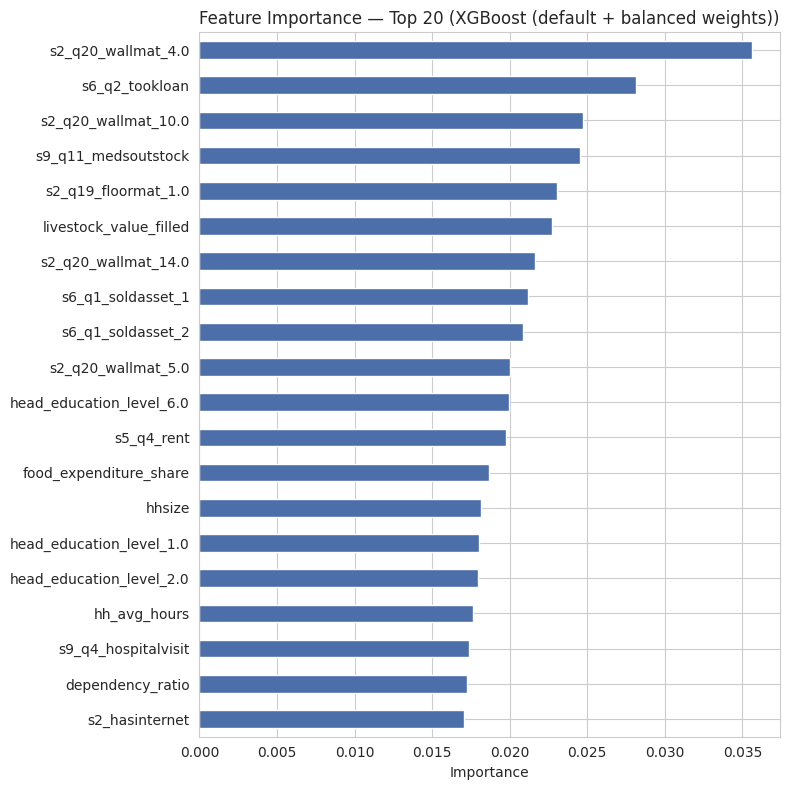

s2_q20_wallmat_4.0          0.035642
s6_q2_tookloan              0.028160
s2_q20_wallmat_10.0         0.024755
s9_q11_medsoutstock         0.024559
s2_q19_floormat_1.0         0.023024
livestock_value_filled      0.022707
s2_q20_wallmat_14.0         0.021620
s6_q1_soldasset_1           0.021193
s6_q1_soldasset_2           0.020835
s2_q20_wallmat_5.0          0.020039
head_education_level_6.0    0.019965
s5_q4_rent                  0.019736
food_expenditure_share      0.018686
hhsize                      0.018174
head_education_level_1.0    0.017993
dtype: float32


In [45]:
def get_importances(m, columns):
    if hasattr(m, 'feature_importances_'):
        vals = m.feature_importances_
    else:  # CatBoost
        vals = m.get_feature_importance()
    return pd.Series(vals, index=columns).sort_values(ascending=False)

importances = get_importances(final_model, final_X_test.columns)

fig, ax = plt.subplots(figsize=(8, 8))
top_n = 20
importances.head(top_n).sort_values().plot(kind='barh', ax=ax, color='#4C6EA9')
ax.set_title(f'Feature Importance — Top {top_n} ({best_name})')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print(importances.head(15))

## 12. Responsible AI Notes

This model predicts a household's *reported experience* of food insecurity — scored
using an HFIAS/CARI-style methodology adapted to the questions this survey actually
asked — from demographic, housing, livelihoods, coping, and social-protection
indicators observed at a single point in time (Wave 4, Jan–Mar 2021, during COVID-19
disruption). It should not be used as a sole determinant of aid eligibility:

- **Adapted, not official, HFIAS.** This survey lacks the diet-quality items in the
  canonical 9-item HFIAS battery (eating less-preferred foods, limited dietary variety,
  eating disliked foods, reducing meal frequency). The Food Insecurity Severity Score
  here is a principled adaptation using the items that *are* available, cross-validated
  against an independent HHS-style score — but it is not directly comparable to HFIAS
  scores computed elsewhere on the full battery.
- **Directional bias.** Check the false-`food_secure` rate above; if the model
  systematically under-predicts insecurity, deploying it for targeting as-is would
  under-serve households that actually need assistance.
- **Point-in-time, not causal.** Predictors like `n_assets_owned` and housing material
  describe standing wealth, not the shock that triggered insecurity; the model cannot
  explain *why* a household is insecure or forecast future risk.
- **Leakage boundaries matter.** `s53_q6_hunger`/`s53_q6_staple` (a second hunger module)
  and `s5_q6a_hungerjan20` (pre-COVID recall) were deliberately excluded from the
  feature set because they measure the same or a closely related construct to the
  target — including them would inflate reported performance without adding real
  predictive information for deployment on new households.
- **Survey-specific and time-bound.** Trained on a COVID-era phone survey; relationships
  between predictors (employment, assets, coping behavior) and food security may shift
  in non-crisis periods or in later waves, and should be re-validated before reuse.

### 12.1 Predict New Households

In [46]:
def preprocess_new_household(raw_data,
                             kept_cols,
                             dropped_cols,
                             cat_cols,
                             bin_cols,
                             num_cols,
                             asset_cols,
                             exp_cols,
                             transfer_value_cols,
                             s2_q21_noadults_median,
                             numeric_medians,
                             county_rate_map,
                             global_insecurity_rate,
                             training_feature_columns):
    """
    Preprocesses raw household data for prediction, replicating the training pipeline.

    Args:
        raw_data (pd.DataFrame or pd.Series): Raw data for one or more households.
                                               Must contain columns similar to the original 'df'
                                               (derived from w4 and a4 merged).
        kept_cols (list): List of columns to keep after initial screening.
        dropped_cols (list): List of columns to drop (were >70% missing in training).
        cat_cols (list): List of categorical columns for one-hot encoding.
        bin_cols (list): List of binary columns.
        num_cols (list): List of numeric columns.
        asset_cols (list): List of asset columns for 'n_assets_owned'.
        exp_cols (list): List of expenditure columns for 'total_expenditure'.
        transfer_value_cols (list): List of transfer value columns.
        s2_q21_noadults_median (float): Median for 's2_q21_noadults' imputation from training data.
        numeric_medians (pd.Series): Medians for other numeric columns imputation from training data.
        county_rate_map (pd.Series): Target encoding map for counties from training data.
        global_insecurity_rate (float): Fallback rate for unknown counties from training data.
        training_feature_columns (pd.Index): The exact columns and their order from the training data.

    Returns:
        pd.DataFrame: Preprocessed data ready for model prediction.
    """
    if isinstance(raw_data, pd.Series):
        # Convert Series to DataFrame, preserving original columns as if it was a row
        processed_df = raw_data.to_frame().T
    else:
        processed_df = raw_data.copy()

    # --- Feature Engineering (Section 5) ---

    # 5.1 Wealth / asset index
    # Ensure all asset_cols are present, fill missing with 0 if they represent absence of asset
    for col in asset_cols:
        if col not in processed_df.columns:
            processed_df[col] = 0
    processed_df['n_assets_owned'] = processed_df[asset_cols].sum(axis=1)

    # 5.2 Agriculture & livestock
    processed_df['is_farming_hh'] = processed_df['s4_q4_acres'].notna().astype(int)
    processed_df['acres_if_farm'] = processed_df['s4_q4_acres'].fillna(0)
    processed_df['livestock_value_filled'] = processed_df['s4_q9_livestockvalue'].fillna(0)

    # 5.3 Enterprise activity, transfers, and expenditure
    processed_df['num_enterprises'] = processed_df['s4_q12_num_ent'].fillna(0)

    for c in transfer_value_cols:
        processed_df[c + '_f'] = processed_df[c].fillna(0)
    processed_df['total_transfer_value'] = processed_df[[c + '_f' for c in transfer_value_cols]].sum(axis=1)

    # Ensure all exp_cols are present for total expenditure calculation
    for col in exp_cols:
        if col not in processed_df.columns:
            processed_df[col] = 0 # Assume 0 if not provided
    processed_df['total_expenditure'] = processed_df[exp_cols].sum(axis=1)
    processed_df['food_expenditure_share'] = np.where(
        processed_df['total_expenditure'] > 0,
        processed_df['s5_q3a_food'].fillna(0) / processed_df['total_expenditure'], # Fill s5_q3a_food for division
        np.nan # If total_exp is 0, food_exp_share is nan, will be filled by median
    )
    # Fill with median from training data
    processed_df['food_expenditure_share'] = processed_df['food_expenditure_share'].fillna(numeric_medians['food_expenditure_share'])

    # 5.4 Demographics: dependency ratio
    processed_df['s2_q21_noadults_f'] = processed_df['s2_q21_noadults'].fillna(s2_q21_noadults_median)
    processed_df['dependency_ratio'] = (
        (processed_df['s2_q15b_schoolchildren'].fillna(0) + processed_df['s2_q15c_youngchildren'].fillna(0))
        / processed_df['s2_q21_noadults_f'].replace(0, 1)
    )

    # --- Missingness Screening (Section 6) ---
    # Drop columns that were deemed >70% missing during training
    cols_to_drop = [c for c in dropped_cols if c in processed_df.columns]
    processed_df = processed_df.drop(columns=cols_to_drop, errors='ignore')

    # Filter to only the 'kept_cols' (and newly engineered ones that are implicitly kept)
    # Re-calculate `num_cols`, `bin_cols`, `cat_cols` based on `kept_cols` for this function's scope
    current_num_cols = [c for c in num_cols if c in kept_cols]
    current_bin_cols = [c for c in bin_cols if c in kept_cols]
    current_cat_cols = [c for c in cat_cols if c in kept_cols]

    # Handle remaining missing values in 'kept' numeric/binary columns
    for c in current_num_cols:
        if c in processed_df.columns and processed_df[c].isnull().any():
            processed_df[c] = processed_df[c].fillna(numeric_medians[c])
        elif c not in processed_df.columns:
            processed_df[c] = numeric_medians[c] # Add if entirely missing from raw_data
    for c in current_bin_cols:
        if c in processed_df.columns and processed_df[c].isnull().any():
            processed_df[c] = processed_df[c].fillna(0)
        elif c not in processed_df.columns:
            processed_df[c] = 0 # Add if entirely missing from raw_data

    # --- Preprocessing (Section 7) ---

    # 7.1 Feature Encoding (One-hot encode categorical features)
    # Convert categorical columns to string to handle potential mixed types and NaNs for get_dummies
    for c in current_cat_cols:
        if c in processed_df.columns:
            processed_df[c] = processed_df[c].fillna('missing').astype(str)
        else:
            processed_df[c] = 'missing' # If a cat column is entirely missing, make it 'missing'

    X_cat_processed = pd.get_dummies(processed_df[current_cat_cols], prefix=current_cat_cols, dtype=int)

    # 7.3 County Target Encoding
    # Ensure 's2_q9a_county' is treated as string for mapping
    county_series_processed = processed_df['s2_q9a_county'].fillna('missing').astype(str)
    processed_df['county_insecurity_rate'] = county_series_processed.map(county_rate_map).fillna(global_insecurity_rate)

    # Combine all features
    final_features_df = pd.concat([
        processed_df[current_bin_cols + current_num_cols].reset_index(drop=True),
        X_cat_processed.reset_index(drop=True),
        processed_df[['county_insecurity_rate']].reset_index(drop=True)
    ], axis=1)

    # Align columns with the training data (critical for prediction)
    # Add any missing columns from training with 0, and remove extra columns
    final_features_df = final_features_df.reindex(columns=training_feature_columns, fill_value=0)

    return final_features_df

# --- Prepare the necessary variables from the training context ---

# Median for 's2_q21_noadults' imputation
s2_q21_noadults_median = df['s2_q21_noadults'].median()

# Medians for other numeric columns imputation
numeric_medians = df[num_cols].median()

# Training feature columns (order and names) for alignment
training_feature_columns = final_X_test.columns

# --- Demonstrate with a sample new household ---

# Simulate raw data for a single new household.
# For demonstration, we'll pick a random household from the original `w4` and `a4` data
# that was NOT part of the test set, and modify it slightly.

# Pick an hhid that is not in the test set
example_hhid_for_prediction = w4[~w4['hhid'].isin(X_test.index)].sample(1, random_state=42)['hhid'].iloc[0]
print(f"\n--- Demonstrating prediction for hhid: {example_hhid_for_prediction} ---")

# Get the raw household record from w4
example_w4_record = w4[w4['hhid'] == example_hhid_for_prediction].copy()
# Get adult records for this household from a4
example_a4_records = a4[a4['hhid'] == example_hhid_for_prediction].copy()

# Recreate aggregation steps from Section 2 for this single household
example_emp_agg = example_a4_records.groupby('hhid').agg(
    any_adult_employed=('employed', 'max'),
    hh_employment_rate=('employed', 'mean'),
    hh_avg_hours=('total_hours', 'mean'),
    any_adult_laidoff=('wholaidoff', 'max'),
).reset_index()
example_mig_agg = example_a4_records.groupby('hhid').agg(
    any_migrant=('migrant_status', 'max')
).reset_index()
example_head_edu = (
    example_a4_records[example_a4_records['ishead'] == 1][['hhid', 'education_level']]
    .rename(columns={'education_level': 'head_education_level'})
)

# Merge them to get the base for our 'new' household, similar to how `df` was constructed initially
new_household_raw_data = (
    example_w4_record.merge(example_emp_agg, on='hhid', how='left')
                     .merge(example_mig_agg, on='hhid', how='left')
                     .merge(example_head_edu, on='hhid', how='left')
)

# Fill NaNs for the aggregated fields as done in the original notebook cell `goDdIoQZbjTm`
new_household_raw_data['any_adult_employed'] = new_household_raw_data['any_adult_employed'].fillna(0)
new_household_raw_data['hh_employment_rate'] = new_household_raw_data['hh_employment_rate'].fillna(0)
new_household_raw_data['hh_avg_hours'] = new_household_raw_data['hh_avg_hours'].fillna(0)
new_household_raw_data['any_adult_laidoff'] = new_household_raw_data['any_adult_laidoff'].fillna(0)
new_household_raw_data['any_migrant'] = new_household_raw_data['any_migrant'].fillna(0)

# Preprocess the new household data
preprocessed_new_data = preprocess_new_household(
    raw_data=new_household_raw_data,
    kept_cols=kept_cols,
    dropped_cols=dropped_cols,
    cat_cols=cat_cols,
    bin_cols=bin_cols,
    num_cols=num_cols,
    asset_cols=asset_cols,
    exp_cols=exp_cols,
    transfer_value_cols=transfer_value_cols,
    s2_q21_noadults_median=s2_q21_noadults_median,
    numeric_medians=numeric_medians,
    county_rate_map=county_rate_map,
    global_insecurity_rate=global_insecurity_rate,
    training_feature_columns=training_feature_columns
)

# Make prediction using the final model
prediction_proba = final_model.predict_proba(preprocessed_new_data)
predicted_class_idx = np.argmax(prediction_proba, axis=1)[0]
predicted_label = le.inverse_transform([predicted_class_idx])[0]

# Display the results
print(f"Predicted Food Security Status: {predicted_label}")
print("Confidence Scores (by class):")
confidence_scores = dict(zip(le.classes_, prediction_proba[0]))
for label, prob in confidence_scores.items():
    print(f"  {label}: {prob:.3f}")

# For comparison, let's see the actual status if this were a known household (only for demonstration)
original_food_status_for_example = df[df['hhid'] == example_hhid_for_prediction]['food_security_status'].iloc[0]
print(f"Actual Food Security Status (for this example household): {original_food_status_for_example}")

# You can change values in `new_household_raw_data` to simulate different households.


--- Demonstrating prediction for hhid: 4091 ---
Predicted Food Security Status: moderately_insecure
Confidence Scores (by class):
  food_secure: 0.211
  mildly_insecure: 0.296
  moderately_insecure: 0.434
  severely_insecure: 0.059
Actual Food Security Status (for this example household): mildly_insecure


## 13. Export Model Artifacts for Deployment
This is **Step 1** from the deployment manual: bundle the fitted model plus
everything `preprocess_new_household()` needs, into one file the web app
loads once at startup. Nothing here needs the raw microdata at serve time --
only this bundle.


In [47]:
import os

# Same values `preprocess_new_household()` (Section 12.1) already computed --
# reused here rather than recomputed, so the export is guaranteed consistent
# with what was actually demonstrated above.
s2_q21_noadults_median = df['s2_q21_noadults'].median()
numeric_medians = df[num_cols].median()
training_feature_columns = final_X_test.columns

artifact_bundle = {
    "model": final_model,
    "label_encoder": le,
    "kept_cols": kept_cols,
    "dropped_cols": dropped_cols,
    "cat_cols": cat_cols,
    "bin_cols": bin_cols,
    "num_cols": num_cols,
    "asset_cols": asset_cols,
    "exp_cols": exp_cols,
    "transfer_value_cols": transfer_value_cols,
    "s2_q21_noadults_median": s2_q21_noadults_median,
    "numeric_medians": numeric_medians,
    "county_rate_map": county_rate_map,
    "global_insecurity_rate": global_insecurity_rate,
    "training_feature_columns": training_feature_columns,
    "best_model_name": best_name,      # documents which candidate this is, for the app/README
}

os.makedirs(path + '../models', exist_ok=True)
with open(path + '../models/model_artifacts.pkl', 'wb') as f:
    pickle.dump(artifact_bundle, f)

print("Saved ../models/model_artifacts.pkl")
print("Bundled model:", best_name)
print("Bundle keys:", list(artifact_bundle.keys()))


Saved ../models/model_artifacts.pkl
Bundled model: XGBoost (default + balanced weights)
Bundle keys: ['model', 'label_encoder', 'kept_cols', 'dropped_cols', 'cat_cols', 'bin_cols', 'num_cols', 'asset_cols', 'exp_cols', 'transfer_value_cols', 's2_q21_noadults_median', 'numeric_medians', 'county_rate_map', 'global_insecurity_rate', 'training_feature_columns', 'best_model_name']
